#**Telco Customer Churn — Pricing & Retention Analysis**

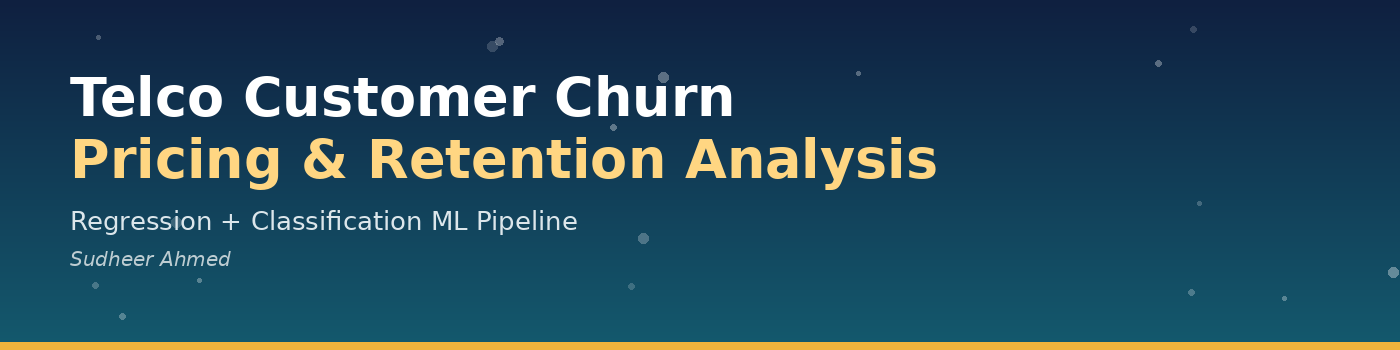

**Intern:** Sudheer Ahmed

**Domain:** Machine Learning

**Company:** DevWerse

**Program:** Internship + Training Program 2026

# Project Objective

The objective of this project is to develop two Machine Learning models using the IBM Telco Customer Churn dataset.

### Regression Task
Predict a customer's **MonthlyCharges** based on their demographic information, subscription plan, and telecom services. This model can help identify unusual pricing, billing inconsistencies, and support pricing analysis.

### Classification Task
Predict whether a customer is likely to **Churn (Yes/No)**. This model enables the retention team to identify customers who are at high risk of leaving and proactively offer retention incentives.

### Project Workflow

The project follows a complete Machine Learning pipeline:

- Importing and understanding the dataset
- Data cleaning and preprocessing
- Exploratory Data Analysis (EDA)
- Feature engineering and encoding
- Building Regression models
- Building Classification models
- Model evaluation using appropriate metrics
- Feature importance analysis
- Business insights and recommendations

This analysis provides valuable insights that can help improve customer retention strategies while ensuring fair and consistent pricing.

#Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

plt.rcParams['figure.figsize'] = (8, 5)
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

#Load Data

In [2]:
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
data = pd.read_csv(url)

print(data.shape)
data.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#Understanding the Dataset

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**Statistical Summary**

In [4]:
data.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Checking Missing Values, Duplicates, and Target Balance**

In [5]:
#Checking missing values
print("Missing values:\n", data.isnull().sum())
print("\nDuplicate customerID:", data['customerID'].duplicated().sum())
print("\nChurn distribution:\n", data['Churn'].value_counts(normalize=True))

Missing values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicate customerID: 0

Churn distribution:
 Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


#**Cleaning TotalCharges**

In [6]:
print("TotalCharges dtype:", data['TotalCharges'].dtype)

# Try converting to numeric, and see which rows fail
bad_rows = data[pd.to_numeric(data['TotalCharges'], errors='coerce').isnull()]
print("\nRows that fail numeric conversion:", len(bad_rows))
bad_rows[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]

TotalCharges dtype: object

Rows that fail numeric conversion: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


Why **pd.to_numeric(..., errors='coerce')** instead of just trying **.astype(float)** directly: **.astype(float)** would crash immediately on the first bad value with a generic error. errors='coerce' instead converts everything it can, and turns anything it can't convert into NaN — letting us find and inspect exactly which rows are the problem before deciding what to do with them.

**Fixing the Blank `TotalCharges` Values**


In [7]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data['TotalCharges'] = data['TotalCharges'].fillna(0)

print("New dtype:", data['TotalCharges'].dtype)
print("Any missing left?", data['TotalCharges'].isnull().sum())
print("\nTotalCharges for tenure=0 customers:")
data[data['tenure'] == 0][['tenure', 'TotalCharges']]

New dtype: float64
Any missing left? 0

TotalCharges for tenure=0 customers:


,tenure,TotalCharges
488,0,0.0
753,0,0.0
936,0,0.0
1082,0,0.0
1340,0,0.0
3331,0,0.0
3826,0,0.0
4380,0,0.0
5218,0,0.0
6670,0,0.0


**fill with 0 instead of the column mean (a common "safe default" for missing numeric data)**: the mean would be factually wrong here — it would claim a customer who's paid nothing has paid the average amount, which contradicts what we just learned about why the value is blank. This is a case where understanding the cause of missingness changes the correct fix — not every missing-value problem should default to mean/median imputation.

#**Exploratory Data Analysis**

**Verify the leakage relationship directly**

count    7043.000000
mean       45.018735
std        49.892509
min         0.000000
25%         9.350000
50%        28.600000
75%        63.625000
max       373.250000
Name: LeakageDiff, dtype: float64


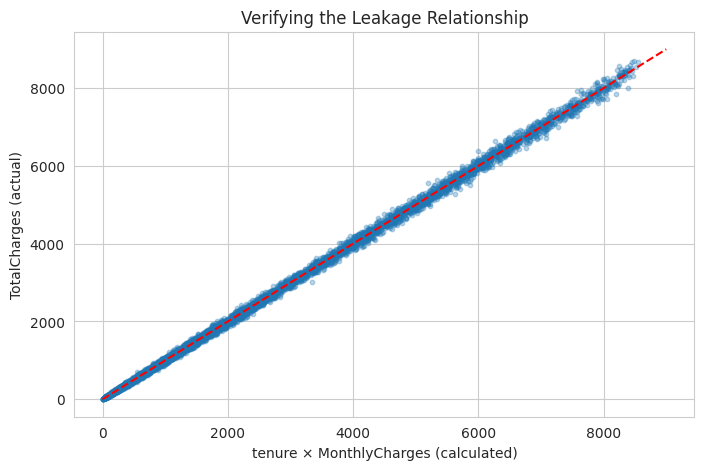

In [8]:
data['ExpectedTotal'] = data['tenure'] * data['MonthlyCharges']
data['LeakageDiff'] = (data['TotalCharges'] - data['ExpectedTotal']).abs()

print(data['LeakageDiff'].describe())

plt.scatter(data['ExpectedTotal'], data['TotalCharges'], alpha=0.3, s=10)
plt.xlabel('tenure × MonthlyCharges (calculated)')
plt.ylabel('TotalCharges (actual)')
plt.title('Verifying the Leakage Relationship')
plt.plot([0, 9000], [0, 9000], color='red', linestyle='--')  # reference line: perfect match
plt.show()

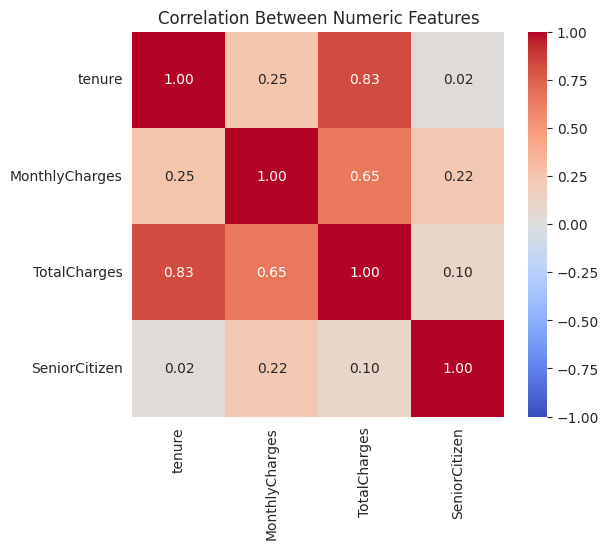

In [84]:
#Correlation Heatmap
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
corr_matrix = data[numeric_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlation Between Numeric Features')
plt.show()

**Quantify the correlation directly**

In [9]:
correlation = data['TotalCharges'].corr(data['ExpectedTotal'])
print(f"Correlation between TotalCharges and tenure×MonthlyCharges: {correlation:.4f}")

correlation_direct = data['TotalCharges'].corr(data['MonthlyCharges'])
print(f"Correlation between TotalCharges and MonthlyCharges alone: {correlation_direct:.4f}")

Correlation between TotalCharges and tenure×MonthlyCharges: 0.9996
Correlation between TotalCharges and MonthlyCharges alone: 0.6512


**MonthlyCharges Distribution**


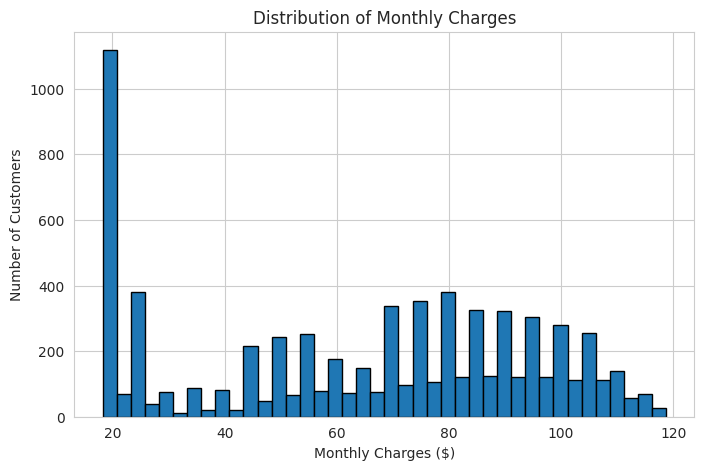

,MonthlyCharges
count,7043.000000
mean,64.761692
std,30.090047
min,18.250000
25%,35.500000
50%,70.350000
75%,89.850000
max,118.750000


In [10]:
plt.hist(data['MonthlyCharges'], bins=40, edgecolor='black')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Number of Customers')
plt.title('Distribution of Monthly Charges')
plt.show()

data['MonthlyCharges'].describe()

**MonthlyCharges by Internet Service Type**


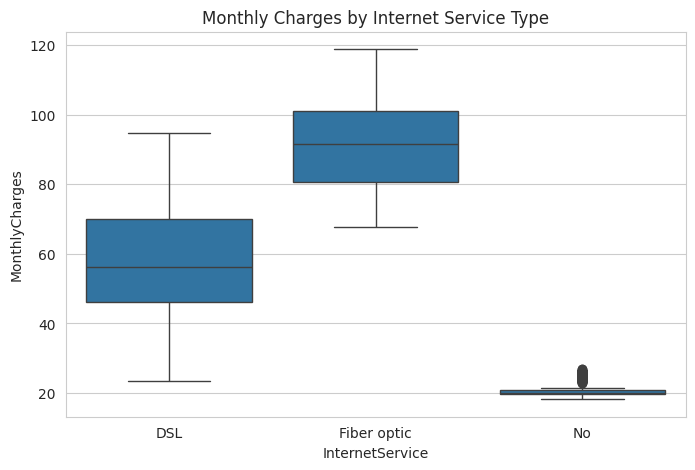

,MonthlyCharges
InternetService,
DSL,58.102169
Fiber optic,91.500129
No,21.079194


In [11]:
sns.boxplot(data=data, x='InternetService', y='MonthlyCharges')
plt.title('Monthly Charges by Internet Service Type')
plt.show()

data.groupby('InternetService')['MonthlyCharges'].mean()

**Churn Rate by Contract**

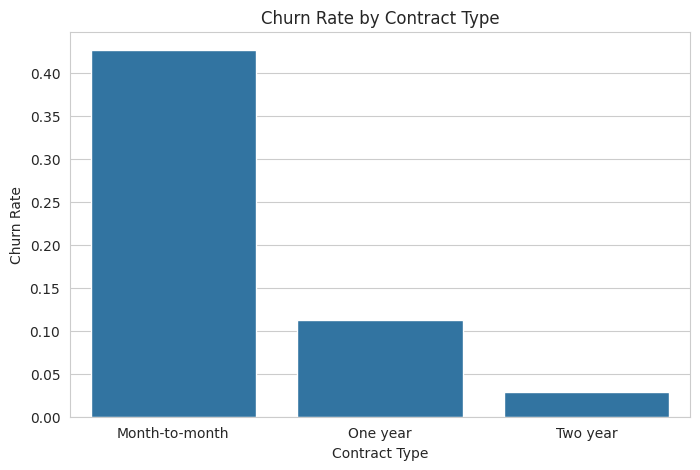

,Churn
Contract,
Month-to-month,0.427097
One year,0.112695
Two year,0.028319


In [12]:
churn_by_contract = data.groupby('Contract')['Churn'].apply(lambda x: (x == 'Yes').mean())

sns.barplot(x=churn_by_contract.index, y=churn_by_contract.values)
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate')
plt.title('Churn Rate by Contract Type')
plt.show()

churn_by_contract

Dramatic pattern — Month-to-month customers churn at ~43%, versus just ~3% for Two-year contracts. That's roughly a 15x difference, confirming Contract will likely be one of the strongest predictors in the classification model.

**Churn Rate by Tenure**

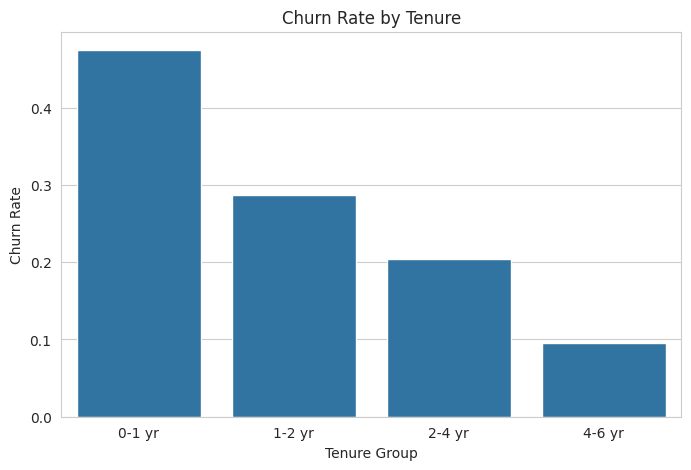

,Churn
TenureGroup,
0-1 yr,0.474382
1-2 yr,0.287109
2-4 yr,0.203890
4-6 yr,0.095132


In [13]:
data['TenureGroup'] = pd.cut(data['tenure'], bins=[0, 12, 24, 48, 72],
                              labels=['0-1 yr', '1-2 yr', '2-4 yr', '4-6 yr'],
                              include_lowest=True)

churn_by_tenure = data.groupby('TenureGroup', observed=True)['Churn'].apply(lambda x: (x == 'Yes').mean())

sns.barplot(x=churn_by_tenure.index, y=churn_by_tenure.values)
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate')
plt.title('Churn Rate by Tenure')
plt.show()

churn_by_tenure

churn drops from ~47% in the first year to under 10% after 4+ years. Strong, monotonic relationship, as expected.

**Churn Rate by MonthlyCharges**

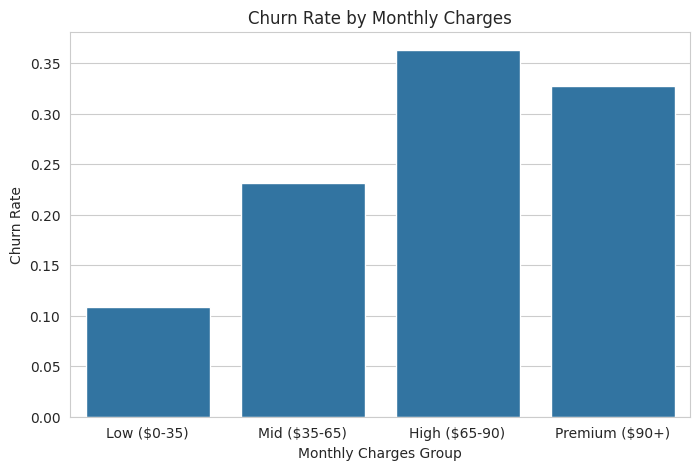

,Churn
ChargeGroup,
Low ($0-35),0.108934
Mid ($35-65),0.231370
High ($65-90),0.362963
Premium ($90+),0.327775


In [14]:
data['ChargeGroup'] = pd.cut(data['MonthlyCharges'], bins=[0, 35, 65, 90, 120],
                              labels=['Low ($0-35)', 'Mid ($35-65)', 'High ($65-90)', 'Premium ($90+)'],
                              include_lowest=True)

churn_by_charge = data.groupby('ChargeGroup', observed=True)['Churn'].apply(lambda x: (x == 'Yes').mean())

sns.barplot(x=churn_by_charge.index, y=churn_by_charge.values)
plt.xlabel('Monthly Charges Group')
plt.ylabel('Churn Rate')
plt.title('Churn Rate by Monthly Charges')
plt.show()

churn_by_charge

churn rises steadily from Low to High ($65-90), then dips slightly at Premium. That's a nuance worth noting: it's not purely "higher price = higher churn," it likely interacts with which service tier customers are in (e.g., Premium customers may be Fiber optic customers who value the service enough to accept the cost, while High-tier customers include more price-sensitive DSL-plus-addons customers).

**Churn by Service Add-ons**

In [15]:
addons = ['OnlineSecurity', 'TechSupport', 'OnlineBackup', 'DeviceProtection']

addon_rates = {}
for col in addons:
    addon_rates[col] = data.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean())

addon_df = pd.DataFrame(addon_rates)
addon_df


,OnlineSecurity,TechSupport,OnlineBackup,DeviceProtection
No,0.417667,0.416355,0.399288,0.391276
No internet service,0.074050,0.074050,0.074050,0.074050
Yes,0.146112,0.151663,0.215315,0.225021


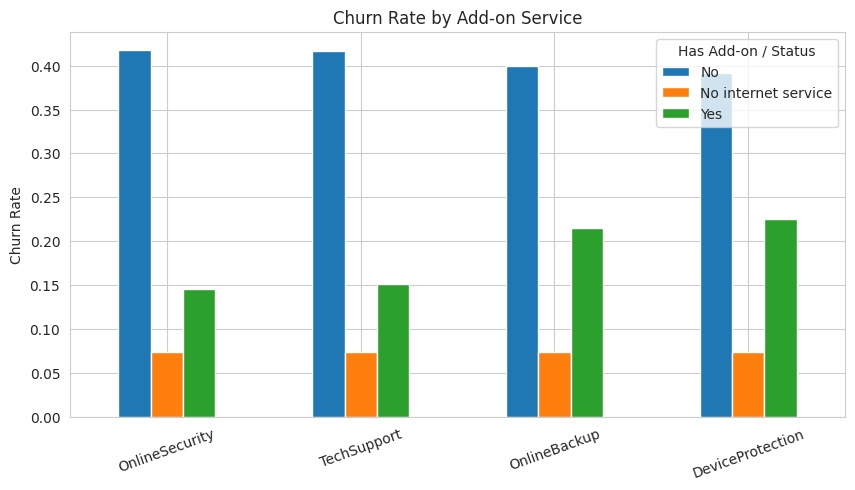

In [16]:
addon_df.T.plot(kind='bar', figsize=(10, 5))
plt.ylabel('Churn Rate')
plt.title('Churn Rate by Add-on Service')
plt.xticks(rotation=20)
plt.legend(title='Has Add-on / Status')
plt.show()

customers with internet service but no
protective add-ons are the highest-risk group (~40% churn) — a plausible
target for proactive outreach or bundling offers.

#**Encoding**

**Binary columns first**

In [17]:
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

for col in binary_cols:
    data[col] = data[col].apply(lambda x: 1 if x == 'Yes' else 0)

data['gender'] = data['gender'].apply(lambda x: 1 if x == 'Male' else 0)

data[binary_cols + ['gender']].head()

,Partner,Dependents,PhoneService,PaperlessBilling,Churn,gender
0,1,0,0,1,0,0
1,0,0,1,0,0,1
2,0,0,1,1,1,1
3,0,0,0,0,0,1
4,0,0,1,1,1,0


**One-Hot Encoding the Remaining Categorical Columns**


In [18]:
multi_cat_cols = [
    'InternetService', 'Contract', 'PaymentMethod', 'MultipleLines',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies'
]

data = pd.get_dummies(data, columns=multi_cat_cols, drop_first=True)
data.shape

(7043, 36)

#**Splitting Features**

**Build the regression feature set**

In [70]:
# Columns to drop for the REGRESSION model (predicting MonthlyCharges)
reg_drop_cols = ['customerID', 'MonthlyCharges', 'TotalCharges', 'Churn',
                  'TenureGroup', 'ChargeGroup', 'ExpectedTotal', 'LeakageDiff']

X_reg = data.drop(columns=reg_drop_cols)
y_reg = data['MonthlyCharges']

print("Regression feature set shape:", X_reg.shape)
X_reg.columns.tolist()

Regression feature set shape: (7043, 28)


['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'PaperlessBilling',
 'InternetService_Fiber optic',
 'InternetService_No',
 'Contract_One year',
 'Contract_Two year',
 'PaymentMethod_Credit card (automatic)',
 'PaymentMethod_Electronic check',
 'PaymentMethod_Mailed check',
 'MultipleLines_No phone service',
 'MultipleLines_Yes',
 'OnlineSecurity_No internet service',
 'OnlineSecurity_Yes',
 'OnlineBackup_No internet service',
 'OnlineBackup_Yes',
 'DeviceProtection_No internet service',
 'DeviceProtection_Yes',
 'TechSupport_No internet service',
 'TechSupport_Yes',
 'StreamingTV_No internet service',
 'StreamingTV_Yes',
 'StreamingMovies_No internet service',
 'StreamingMovies_Yes']

**Build the classification feature set**

In [71]:
# Columns to drop for the CLASSIFICATION model (predicting Churn)
clf_drop_cols = ['customerID', 'Churn', 'TenureGroup', 'ChargeGroup',
                  'ExpectedTotal', 'LeakageDiff']

X_clf = data.drop(columns=clf_drop_cols)
y_clf = data['Churn']

print("Classification feature set shape:", X_clf.shape)
X_clf.columns.tolist()

Classification feature set shape: (7043, 30)


['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'PaperlessBilling',
 'MonthlyCharges',
 'TotalCharges',
 'InternetService_Fiber optic',
 'InternetService_No',
 'Contract_One year',
 'Contract_Two year',
 'PaymentMethod_Credit card (automatic)',
 'PaymentMethod_Electronic check',
 'PaymentMethod_Mailed check',
 'MultipleLines_No phone service',
 'MultipleLines_Yes',
 'OnlineSecurity_No internet service',
 'OnlineSecurity_Yes',
 'OnlineBackup_No internet service',
 'OnlineBackup_Yes',
 'DeviceProtection_No internet service',
 'DeviceProtection_Yes',
 'TechSupport_No internet service',
 'TechSupport_Yes',
 'StreamingTV_No internet service',
 'StreamingTV_Yes',
 'StreamingMovies_No internet service',
 'StreamingMovies_Yes']

#**Regression Model**

**Split**

In [72]:
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print("Train shape:", X_reg_train.shape)
print("Test shape:", X_reg_test.shape)

Train shape: (5634, 28)
Test shape: (1409, 28)


**Train Linear Regression**

In [73]:
lin_reg = LinearRegression()
lin_reg.fit(X_reg_train, y_reg_train)

lin_reg_preds = lin_reg.predict(X_reg_test)

print("Linear Regression trained.")

Linear Regression trained.


#**Random Forest Regressor**

In [74]:
forest_reg = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
forest_reg.fit(X_reg_train, y_reg_train)

forest_reg_preds = forest_reg.predict(X_reg_test)

print("Random Forest Regressor trained.")

Random Forest Regressor trained.


#**Evaluating Both Regression Models**

In [75]:
def evaluate_regression(name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        'Model': name,
        'MSE': mse,
        'RMSE': np.sqrt(mse),
        'R2': r2_score(y_true, y_pred)
    }

reg_results = pd.DataFrame([
    evaluate_regression('Linear Regression', y_reg_test, lin_reg_preds),
    evaluate_regression('Random Forest', y_reg_test, forest_reg_preds)
])

reg_results

,Model,MSE,RMSE,R2
0,Linear Regression,1.105210,1.051290,0.998779
1,Random Forest,1.527093,1.235756,0.998313


**Interpreting the Regression Results**

Linear Regression and Random Forest perform almost identically (R² 0.9988 vs
0.9983), so the simpler, fully interpretable Linear Regression is the better
choice — its coefficients directly show how much each service adds to the
bill (Fiber optic internet ≈ +$25/month, each streaming service ≈ +$10/month,
each support/security add-on ≈ +$5/month). This confirms the telecom's pricing
is close to additive and formulaic.

**Chosen model: Linear Regression** — for the retention team's pricing-error
use case, a customer whose actual `MonthlyCharges` deviates notably from what
their selected services predict is a real anomaly worth investigating
(billing mistake, grandfathered discount, negotiated rate).

**Confirm no leakage columns slipped through**

In [76]:
print("Confirming excluded columns are NOT in X_reg:")
for col in ['TotalCharges', 'Churn', 'ChargeGroup', 'TenureGroup']:
    print(f"  {col}: {'PRESENT (bug!)' if col in X_reg.columns else 'correctly excluded'}")

# Check Linear Regression's coefficients — if pricing is genuinely additive
# by service, a handful of coefficients should dominate
coefs = pd.Series(lin_reg.coef_, index=X_reg.columns).sort_values(key=abs, ascending=False)
coefs.head(10)

Confirming excluded columns are NOT in X_reg:
  TotalCharges: correctly excluded
  Churn: correctly excluded
  ChargeGroup: correctly excluded
  TenureGroup: correctly excluded


,0
InternetService_Fiber optic,24.948151
PhoneService,10.017320
MultipleLines_No phone service,-10.017320
StreamingTV_Yes,9.986906
StreamingMovies_Yes,9.951051
OnlineSecurity_Yes,5.055063
TechSupport_Yes,5.039899
MultipleLines_Yes,5.018460
DeviceProtection_Yes,5.018438
OnlineBackup_Yes,4.986724


#**Classification Model**

**Split**

In [77]:
X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print("Train churn rate:", y_clf_train.mean())
print("Test churn rate:", y_clf_test.mean())

Train churn rate: 0.2653532126375577
Test churn rate: 0.2654364797728886


**Class weighting**

In [78]:
from sklearn.utils.class_weight import compute_class_weight

clf_class_weights = compute_class_weight('balanced', classes=np.unique(y_clf_train), y=y_clf_train)
clf_class_weight_dict = dict(zip(np.unique(y_clf_train), clf_class_weights))
clf_class_weight_dict

{np.int64(0): np.float64(0.6805991785455424),
 np.int64(1): np.float64(1.8842809364548494)}

**Train Logistic Regression**

In [79]:
log_reg_clf = LogisticRegression(class_weight=clf_class_weight_dict, max_iter=2000, random_state=42)
log_reg_clf.fit(X_clf_train, y_clf_train)

log_reg_clf_preds = log_reg_clf.predict(X_clf_test)
log_reg_clf_probs = log_reg_clf.predict_proba(X_clf_test)[:, 1]

print("Logistic Regression (Churn) trained.")

Logistic Regression (Churn) trained.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**Fixing the Convergence** **Warning**

In [80]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_clf_train_scaled = pd.DataFrame(scaler.fit_transform(X_clf_train), columns=X_clf_train.columns, index=X_clf_train.index)
X_clf_test_scaled = pd.DataFrame(scaler.transform(X_clf_test), columns=X_clf_test.columns, index=X_clf_test.index)

log_reg_clf = LogisticRegression(class_weight=clf_class_weight_dict, max_iter=1000, random_state=42)
log_reg_clf.fit(X_clf_train_scaled, y_clf_train)

log_reg_clf_preds = log_reg_clf.predict(X_clf_test_scaled)
log_reg_clf_probs = log_reg_clf.predict_proba(X_clf_test_scaled)[:, 1]

print("Logistic Regression (Churn) trained — scaled, no warning expected.")

Logistic Regression (Churn) trained — scaled, no warning expected.


**Random Forest**

In [81]:
forest_clf = RandomForestClassifier(
    n_estimators=200, class_weight=clf_class_weight_dict,
    max_depth=10, random_state=42, n_jobs=-1
)
forest_clf.fit(X_clf_train, y_clf_train)

forest_clf_preds = forest_clf.predict(X_clf_test)
forest_clf_probs = forest_clf.predict_proba(X_clf_test)[:, 1]

print("Random Forest (Churn) trained.")

Random Forest (Churn) trained.


**Train XGBoost**

In [82]:
!pip install xgboost -q
from xgboost import XGBClassifier

scale_pos_weight_clf = (y_clf_train == 0).sum() / (y_clf_train == 1).sum()

xgb_clf = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight_clf, random_state=42,
    eval_metric='logloss', n_jobs=-1
)
xgb_clf.fit(X_clf_train, y_clf_train)

xgb_clf_preds = xgb_clf.predict(X_clf_test)
xgb_clf_probs = xgb_clf.predict_proba(X_clf_test)[:, 1]

print("XGBoost (Churn) trained.")

XGBoost (Churn) trained.


#**Churn Model Evaluation**

In [88]:
def evaluate_model(name, y_true, y_pred, y_prob):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_prob)
    }

clf_results = pd.DataFrame([
    evaluate_model('Logistic Regression', y_clf_test, log_reg_clf_preds, log_reg_clf_probs),
    evaluate_model('Random Forest', y_clf_test, forest_clf_preds, forest_clf_probs),
    evaluate_model('XGBoost', y_clf_test, xgb_clf_preds, xgb_clf_probs)
])

clf_results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.740241,0.506897,0.786096,0.616352,0.841401
1,Random Forest,0.769340,0.549696,0.724599,0.625144,0.841842
2,XGBoost,0.762243,0.538767,0.724599,0.618016,0.833926


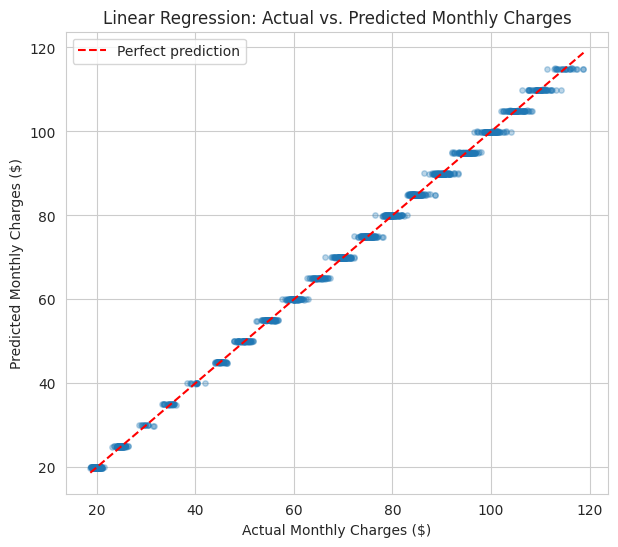

In [85]:
#Actual vs. Predicted (Regression)
plt.figure(figsize=(7, 6))
plt.scatter(y_reg_test, lin_reg_preds, alpha=0.3, s=15)
plt.plot([y_reg_test.min(), y_reg_test.max()], [y_reg_test.min(), y_reg_test.max()],
         color='red', linestyle='--', label='Perfect prediction')
plt.xlabel('Actual Monthly Charges ($)')
plt.ylabel('Predicted Monthly Charges ($)')
plt.title('Linear Regression: Actual vs. Predicted Monthly Charges')
plt.legend()
plt.show()

**Interpreting the Churn Results**

Random Forest has the best overall balance — highest Accuracy, F1, and
ROC-AUC. Logistic Regression catches slightly more real churners (Recall
0.786 vs 0.725) but with more false alarms (lower Precision).

**Chosen model: Random Forest** — best overall balance for the retention
team's use case. Logistic Regression is a reasonable alternative if the
team's cost-per-retention-offer is low enough that catching more churners
outweighs the extra false alarms.

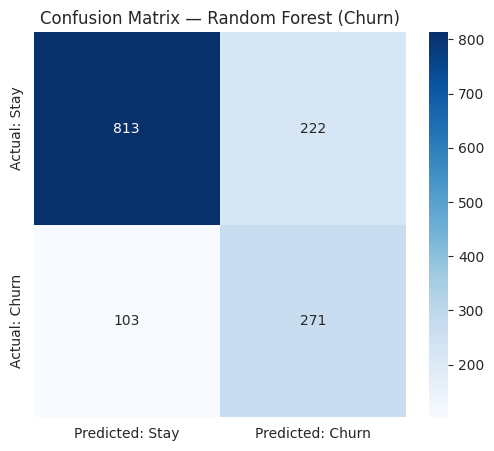

In [86]:
#Confusion Matrix
cm = confusion_matrix(y_clf_test, forest_clf_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: Stay', 'Predicted: Churn'],
            yticklabels=['Actual: Stay', 'Actual: Churn'])
plt.title('Confusion Matrix — Random Forest (Churn)')
plt.show()

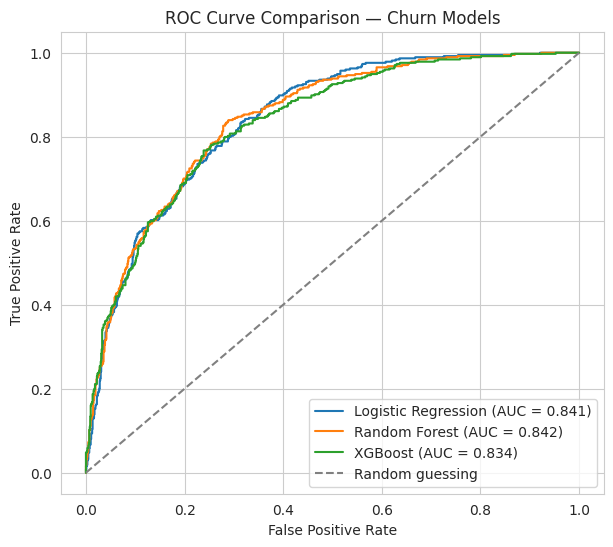

In [87]:
#ROC Curve Overlay
from sklearn.metrics import roc_curve

plt.figure(figsize=(7, 6))

for name, probs in [
    ('Logistic Regression', log_reg_clf_probs),
    ('Random Forest', forest_clf_probs),
    ('XGBoost', xgb_clf_probs)
]:
    fpr, tpr, _ = roc_curve(y_clf_test, probs)
    auc = roc_auc_score(y_clf_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison — Churn Models')
plt.legend()
plt.show()

#**Feature Importance**

In [61]:
clf_importances = pd.Series(forest_clf.feature_importances_, index=X_clf.columns)
top_clf_features = clf_importances.sort_values(ascending=False).head(15)

top_clf_features

,0
tenure,0.174993
TotalCharges,0.145970
Contract_Two year,0.101013
MonthlyCharges,0.100570
InternetService_Fiber optic,0.076758
PaymentMethod_Electronic check,0.048784
Contract_One year,0.042005
OnlineSecurity_Yes,0.027386
TechSupport_Yes,0.025262
PaperlessBilling,0.020377


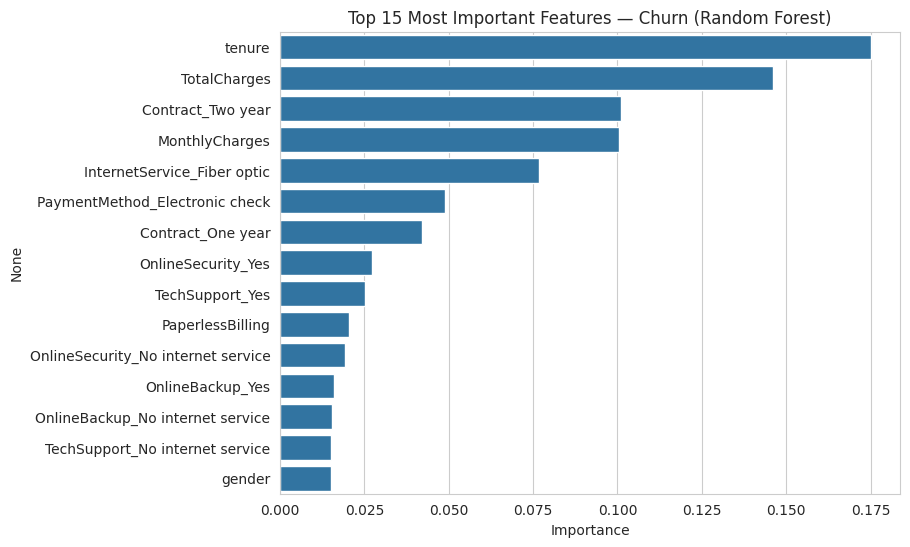

In [62]:
#Visualize
plt.figure(figsize=(8, 6))
sns.barplot(x=top_clf_features.values, y=top_clf_features.index)
plt.xlabel('Importance')
plt.title('Top 15 Most Important Features — Churn (Random Forest)')
plt.show()



## **Recommendations for the Retention Team**

**Pricing model takeaways:**
- Pricing is highly predictable from services subscribed — Fiber optic
  internet and streaming add-ons are the biggest drivers of monthly cost.
- Use this model to flag customers whose actual charges deviate significantly
  from their predicted price — these are candidates for billing review or
  negotiation follow-up.

**Churn model takeaways:**
- The strongest churn predictors are `tenure`, `TotalCharges`, `Contract`
  type, and `MonthlyCharges` — newer, month-to-month, higher-paying customers
  are the highest-risk group.
- Customers with internet service but no security/support add-ons churn at
  roughly 40%, compared to ~15-22% for those with add-ons — a plausible
  bundling or outreach opportunity.
- Prioritize retention offers for new (low-tenure) month-to-month customers
  on Fiber optic plans — this segment combines the three strongest risk
  factors identified by the model.

**Save both final models**

In [89]:
import joblib

joblib.dump(forest_clf, 'random_forest_churn.pkl')
joblib.dump(lin_reg, 'linear_regression_monthlycharges.pkl')

print("Models saved:")
print("  random_forest_churn.pkl")
print("  linear_regression_monthlycharges.pkl")

Models saved:
  random_forest_churn.pkl
  linear_regression_monthlycharges.pkl


In [90]:
from google.colab import files

files.download('random_forest_churn.pkl')
files.download('linear_regression_monthlycharges.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Conclusion

This project built two models on the same telecom dataset to serve two
different business needs.

The **regression model** (Linear Regression, R² = 0.9988) showed that
`MonthlyCharges` is almost entirely explained by which services a customer
subscribes to — internet type and add-ons combine in a near-additive,
predictable way. This makes it a reliable tool for spotting billing anomalies.

The **classification model** (Random Forest, ROC-AUC = 0.842) showed that
churn is driven mainly by `tenure`, `Contract` type, and `MonthlyCharges` —
newer, month-to-month, higher-paying customers are the highest-risk group.
Handling the ~27% class imbalance with class weighting was essential, since
raw accuracy alone would have hidden the model's ability to catch real
churners.

Throughout, care was taken to avoid data leakage — most notably excluding
`TotalCharges`-derived features from the regression model, since they were
functionally circular with the target itself.

**Save and download the cleaned dataset**

In [91]:
data.to_csv('Telco-Customer-Churn-Cleaned.csv', index=False)

from google.colab import files
files.download('Telco-Customer-Churn-Cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>